# Comparison of in vitro endothelium with in vivo embryos

In [1]:
here::i_am("revisions/06_endothelium_verification/01_endothelium_comparison_atlases.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [98]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# ATAC_sce
args$atac_sce = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')


In [3]:
# Load meta
meta = fread(args$metadata) %>% 
    .[celltype_v2 == 'Endothelium']  # Only WT cells for celltype marker search

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

#### Quick plot of endothelial markers

In [5]:
head(meta)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,stage.mapped_mnn,cellstage.score_mnn,closest.cell_mnn,celltype_genotype,celltype_extended_genotype,UMAP1,UMAP2,mofa_cluster,celltype_v1,celltype_v2
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>
2_Eo_DEG_G9_day4_VC#GTACTGGTCTTAAGTG-1,GTACTGGTCTTAAGTG-1,2_Eo_DEG_G9_day4_VC,4603,14339,6.17,6.82,day4_WT_rep2,D4,WT,⋯,E8.5,0.56,cell_92339,Endothelium-WT,Venous_endothelium-WT,7.110783,0.9862596,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_VC#TGGACCGGTTGGGTTA-1,TGGACCGGTTGGGTTA-1,2_Eo_DEG_G9_day4_VC,3661,9320,5.46,14.28,day4_WT_rep2,D4,WT,⋯,E7.0,0.40,cell_88290,Mixed_mesoderm-WT,Lateral_plate_mesoderm-WT,6.922214,1.0375621,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_VC#TGTGCACCAGCAAGGC-1,TGTGCACCAGCAAGGC-1,2_Eo_DEG_G9_day4_VC,4288,12321,4.91,8.77,day4_WT_rep2,D4,WT,⋯,E8.5,0.64,cell_92339,Haematoendothelial_progenitors-WT,Venous_endothelium-WT,7.277101,0.9686094,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_dTAG#AACAGATAGTTGGATC-1,AACAGATAGTTGGATC-1,2_Eo_DEG_G9_day4_dTAG,3061,8064,9.40,17.88,day4_KO_rep2,D4,KO,⋯,E8.0,0.56,cell_73455,ExE_mesoderm-KO,Lateral_plate_mesoderm-KO,7.482838,1.1158436,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_dTAG#ACGGGAAGTGATGGCT-1,ACGGGAAGTGATGGCT-1,2_Eo_DEG_G9_day4_dTAG,3434,8545,11.83,9.50,day4_KO_rep2,D4,KO,⋯,E8.5,0.32,cell_99233,Endothelium-KO,Venous_endothelium-KO,7.350658,1.3768554,15,Endothelium,Endothelium
2_Eo_DEG_G9_day4_dTAG#CACCGGTAGCCTGATG-1,CACCGGTAGCCTGATG-1,2_Eo_DEG_G9_day4_dTAG,4658,14306,3.45,7.99,day4_KO_rep2,D4,KO,⋯,E8.5,0.32,cell_12207,Endothelium-KO,Venous_endothelium-KO,7.353368,1.0704208,15,Endothelium,Endothelium


In [6]:
subset_markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/SS2/Endothelial_subset_markers.txt')

In [7]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[,head(.SD, 15), by = 'cluster'] %>% 
    .[gene %in% rownames(rna.sce)]

In [8]:
tmp = mclapply(unique(top_markers$gene), function(x){
    tmp = meta %>% copy() %>%
    .[,value := minmax.normalisation(as.vector(logcounts(rna.sce[x,meta$cell])))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

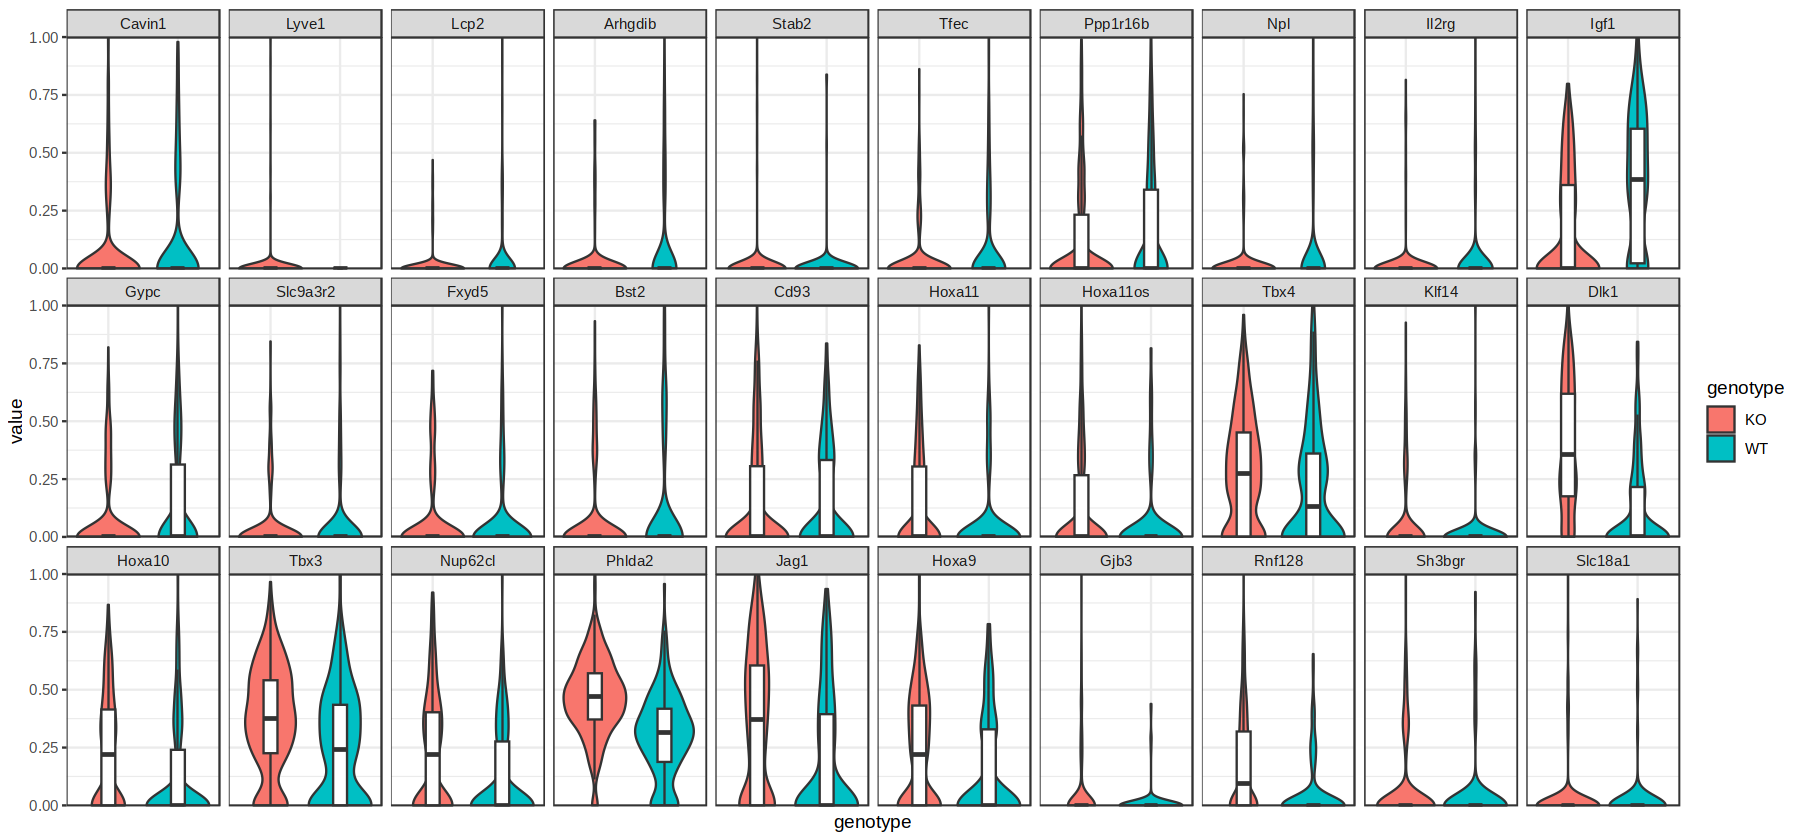

In [9]:
options(repr.plot.height=7, repr.plot.width = 15)

ggplot(tmp, aes(genotype, value, fill = genotype)) + 
    geom_violin() + 
    geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA) + 
    facet_wrap(~gene, ncol = 10) + 
    scale_y_continuous(expand = c(0,0)) + 
    theme_bw() + 
    theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

In [10]:
head(top_markers)

cluster,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
yolk sac,2.852431e-34,2.070508,0.911,0.219,1.433033e-29,Cavin1
yolk sac,3.475243e-34,2.048852,0.989,0.469,1.745927e-29,Lyve1
yolk sac,7.480506e-34,2.353611,0.822,0.106,3.758132e-29,Lcp2
yolk sac,5.302134e-31,1.307636,0.956,0.562,2.663739e-26,Arhgdib
yolk sac,3.618046e-29,2.462631,0.733,0.081,1.817670e-24,Stab2
yolk sac,2.478745e-28,2.006054,0.778,0.100,1.245297e-23,Tfec


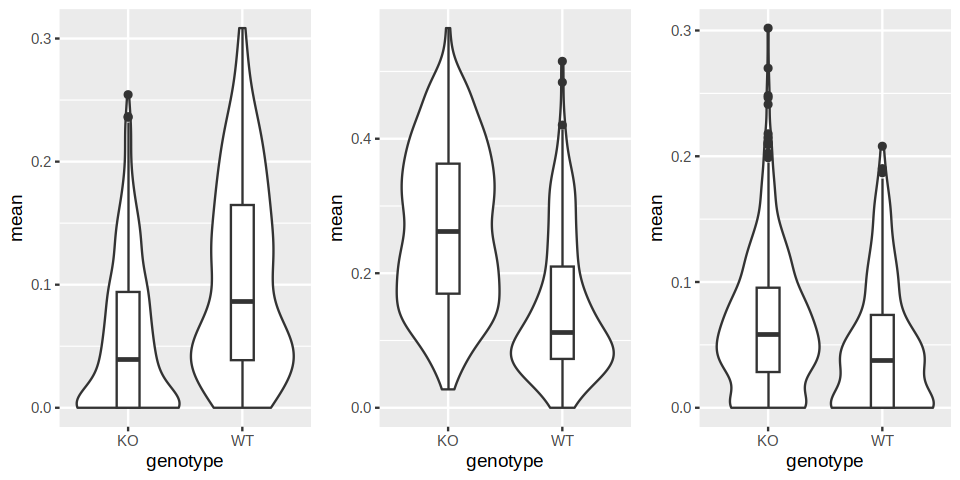

In [11]:
top_markers = subset_markers %>% 
     #.[cluster != 'embryo'] %>%
    .[,head(.SD, 10), by = 'cluster'] %>% 
    .[gene %in% rownames(rna.sce)]

tmp = mclapply(unique(top_markers$gene), function(x){
    tmp = meta %>% copy() %>%
    .[,value := minmax.normalisation(as.vector(logcounts(rna.sce[x,meta$cell])))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'yolk sac', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p1 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'allantois', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p2 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'embryo', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p3 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

options(repr.plot.height=4, repr.plot.width = 8)
ggarrange(p1, p2, p3, nrow = 1)

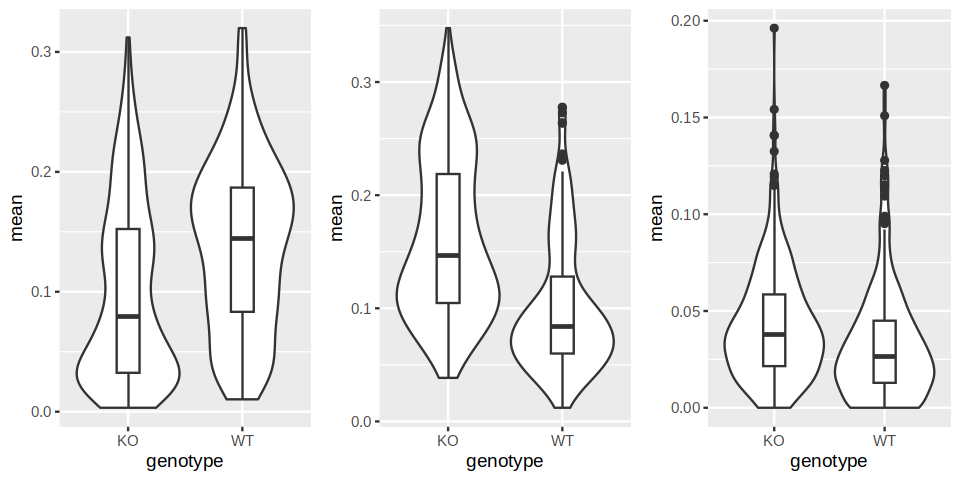

In [12]:
top_markers = subset_markers %>% 
     #.[cluster != 'embryo'] %>%
    .[,head(.SD, 50), by = 'cluster'] %>% 
    .[gene %in% rownames(rna.sce)]

tmp = mclapply(unique(top_markers$gene), function(x){
    tmp = meta %>% copy() %>%
    .[,value := minmax.normalisation(as.vector(logcounts(rna.sce[x,meta$cell])))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'yolk sac', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p1 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'allantois', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p2 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% top_markers[cluster == 'embryo', gene]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p3 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

options(repr.plot.height=4, repr.plot.width = 8)
ggarrange(p1, p2, p3, nrow = 1)

In [120]:
multiome_markers =  fread(file.path(io$basedir, 'figures/vivo_allantois_vs_ys_endothelium_RNA.txt.gz'))[order(-abs(logFC))]

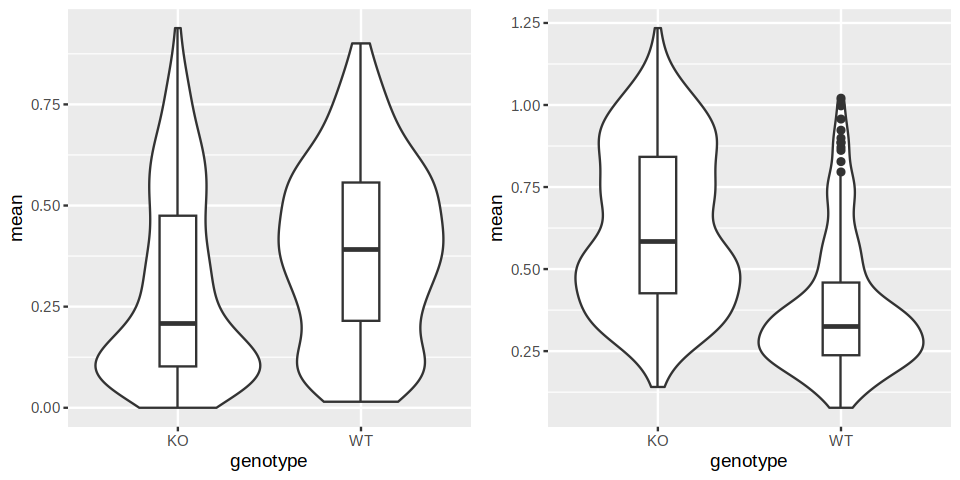

In [121]:
top_n = 50

YS_markers = multiome_markers[logFC > 0.5 & padj_fdr < 0.05, gene] 
YS_markers = YS_markers[YS_markers %in% rownames(rna.sce)] %>% head(top_n)
allantois_markers = multiome_markers[logFC < -0.5 & padj_fdr < 0.05, gene] 
allantois_markers = allantois_markers[allantois_markers %in% rownames(rna.sce)] %>% head(top_n)


tmp = mclapply(YS_markers, function(x){
    tmp = meta %>% copy() %>%
    .[,value := as.vector(logcounts(rna.sce[x,meta$cell]))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)]

tmp1 = tmp %>% copy %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p1 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp = mclapply(allantois_markers, function(x){
    tmp = meta %>% copy() %>%
    .[,value := as.vector(logcounts(rna.sce[x,meta$cell]))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)]

tmp1 = tmp %>% copy %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p2 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

options(repr.plot.height=4, repr.plot.width = 8)
ggarrange(p1, p2, nrow = 1)

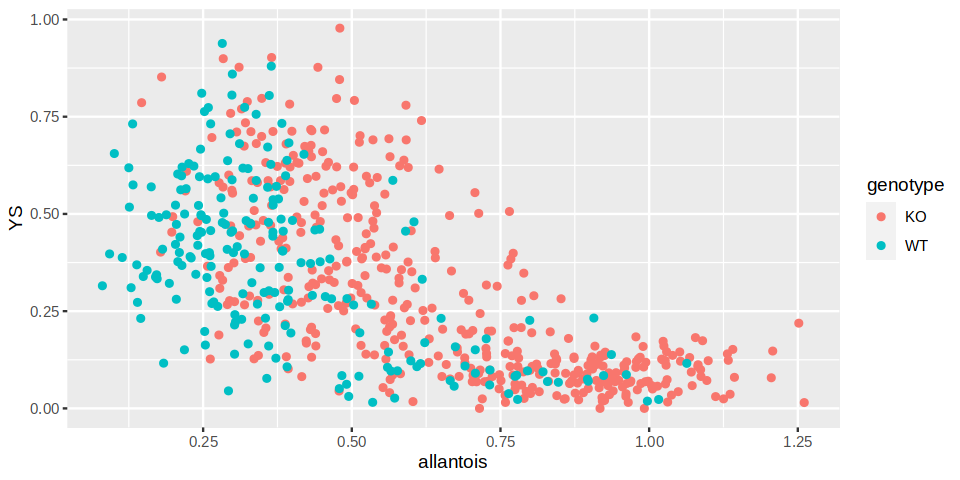

In [124]:
top_n = 50

YS_markers = multiome_markers[logFC > 0.5 & padj_fdr < 0.05, gene] %>% head(top_n)
YS_markers = YS_markers[YS_markers %in% rownames(rna.sce)]
allantois_markers = multiome_markers[logFC < -0.5 & padj_fdr < 0.05, gene] %>% head(top_n)
allantois_markers = allantois_markers[allantois_markers %in% rownames(rna.sce)]


tmp1 = mclapply(YS_markers, function(x){
    tmp = meta %>% copy() %>%
    .[,value := as.vector(logcounts(rna.sce[x,meta$cell]))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)]%>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')

tmp2 = mclapply(allantois_markers, function(x){
    tmp = meta %>% copy() %>%
    .[,value := as.vector(logcounts(rna.sce[x,meta$cell]))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)]%>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')

tmp3 = data.table(allantois = tmp2$mean,
           YS = tmp1$mean,
            genotype = tmp1$genotype)

ggplot(tmp3, aes(allantois, YS, color = genotype)) + 
    geom_point()

#### ATAC

In [99]:
# load atac sce
atac.sce <- readRDS(args$atac_sce)

In [101]:
assay(atac.sce, 'counts') = assay(atac.sce, 'PeakMatrix')

In [104]:
assay(atac.sce, 'PeakMatrix') = NULL

In [106]:
atac.sce = as(atac.sce, 'SingleCellExperiment')

In [109]:
atac.sce = atac.sce[,meta$cell]

In [111]:
colData(atac.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [146]:
multiome_markers = fread(file.path(io$basedir, 'figures/vivo_allantois_vs_ys_endothelium_ATAC.txt.gz'))[order(-abs(logFC))]

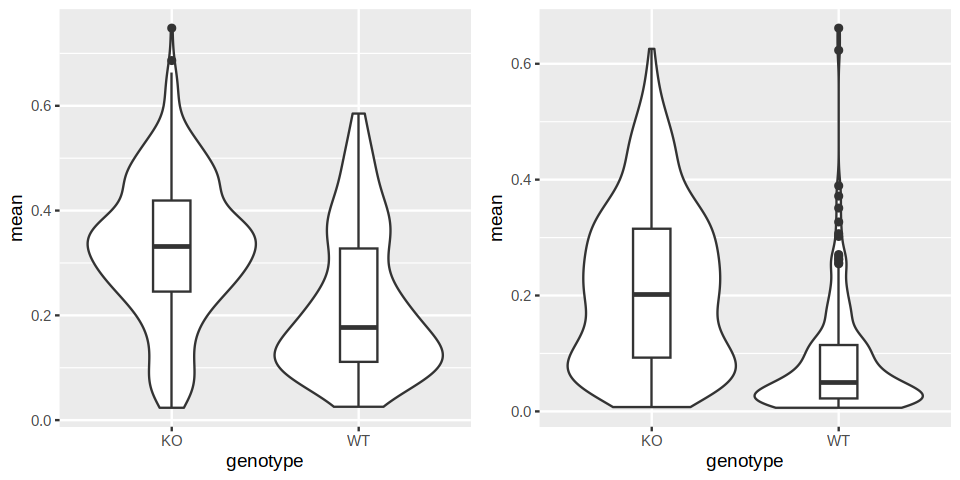

In [152]:
top_n = 5000

YS_markers = multiome_markers[logFC > 0.25 & padj_fdr < 0.05, gene] 
YS_markers = YS_markers[YS_markers %in% rownames(atac.sce)] %>% head(top_n)
length(YS_markers)
allantois_markers = multiome_markers[logFC < -0.25 & padj_fdr < 0.05, gene]
allantois_markers = allantois_markers[allantois_markers %in% rownames(atac.sce)] %>% head(top_n)
length(allantois_markers)

# Score reflects average % of cells that have accessibility
tmp = mclapply(YS_markers, function(x){
    tmp = meta %>% copy() %>%
    .[,value := as.vector(counts(atac.sce[x,meta$cell])>0)] %>%  # >0 binarises in order to tranform score into % of cells
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)]

tmp1 = tmp %>% copy %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p1 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp = mclapply(allantois_markers, function(x){
    tmp = meta %>% copy() %>%
    .[,value := as.vector(counts(atac.sce[x,meta$cell])>0)] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)]

tmp1 = tmp %>% copy %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p2 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

options(repr.plot.height=4, repr.plot.width = 8)
ggarrange(p1, p2, nrow = 1)

#### Atlas

In [434]:
# Load Atlas
args$atlas.sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/endothelium/endothelium_sce.rds'
atlas.sce = load_SingleCellExperiment(args$atlas.sce, normalise = TRUE) 
atlas.sce = atlas.sce[,atlas.sce$seurat_cluster %in% c('YS_endothelium', 'Allantois_endothelium')]

In [435]:
atlas_meta = colData(atlas.sce) %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [280]:
tmp = mclapply(unique(top_markers$gene), function(x){
    tmp = atlas_meta %>% copy() %>%
    .[,value := as.vector(logcounts(atlas.sce[x,atlas_meta$cell]))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

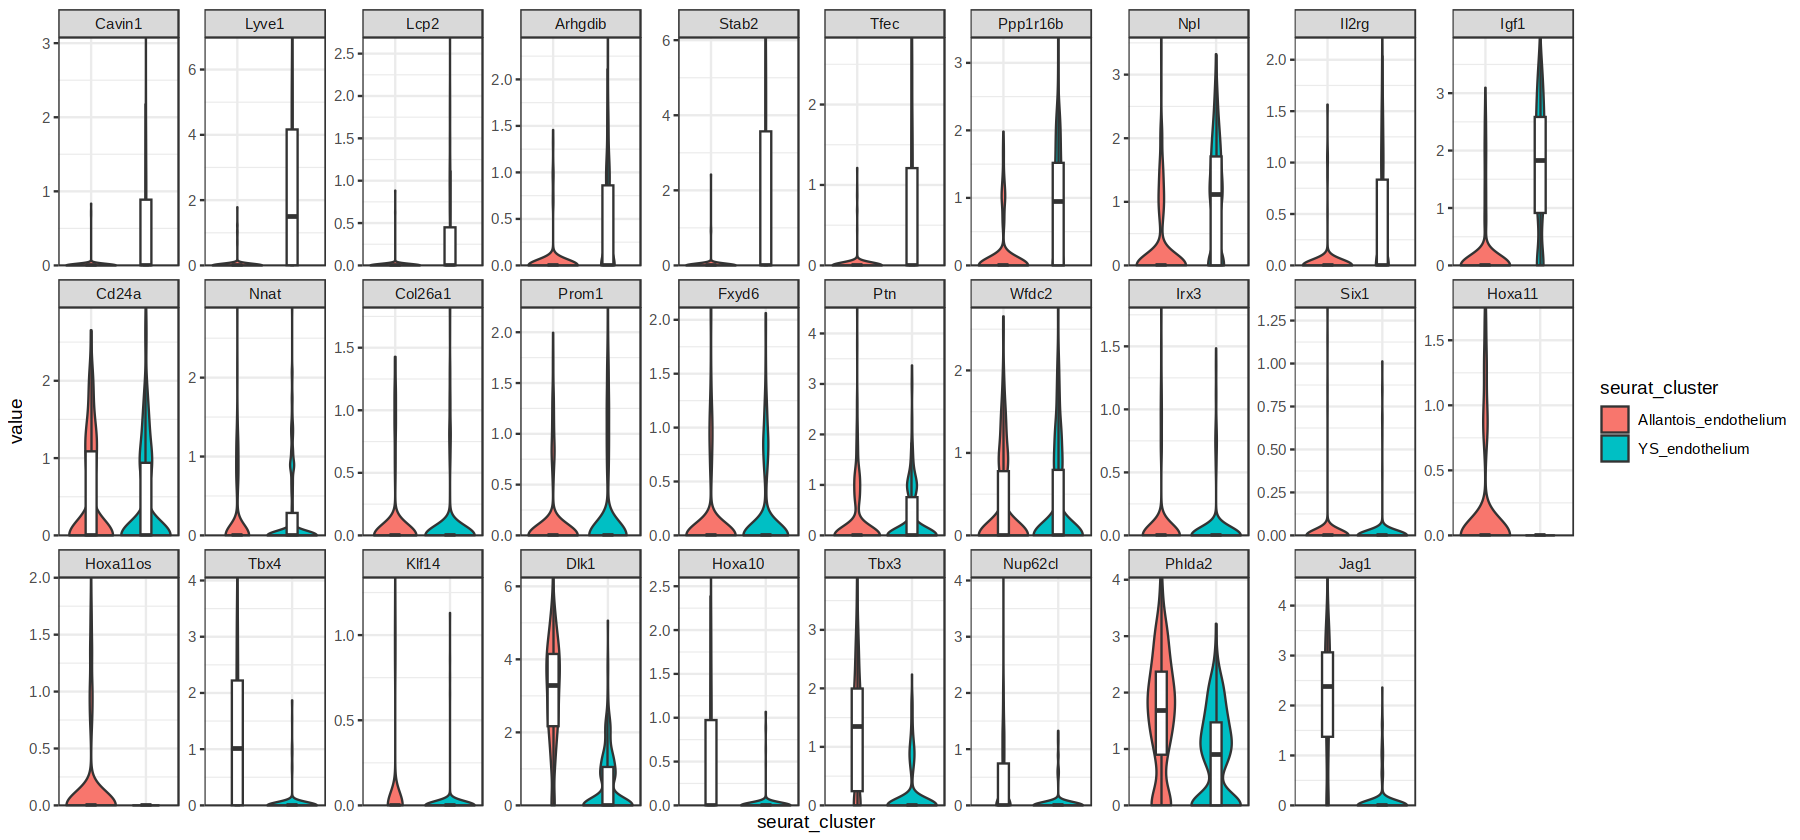

In [282]:
options(repr.plot.height=7, repr.plot.width = 15)
ggplot(tmp, aes(seurat_cluster, value, fill = seurat_cluster)) + 
    geom_violin() + 
    geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA) + 
    facet_wrap(~gene, ncol = 10, scale = 'free') + 
    scale_y_continuous(expand = c(0,0)) + 
    theme_bw() + 
    theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

In [487]:
seurat = as.Seurat(atlas.sce)
Idents(seurat) = seurat$seurat_cluster
markers = as.data.table(FindMarkers(seurat, ident.1 = 'YS_endothelium', ident.2 = 'Allantois_endothelium'), keep.rownames=T) %>%
    .[, sig := ifelse(avg_log2FC > 0 & p_val_adj < 0.05, 'pos',
                      ifelse(avg_log2FC < 0 & p_val_adj < 0.05, 'neg',
                             'nonsig'))]

In [488]:
head(markers)

rn,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Jag1,2.198402e-90,-1.500614,0.108,0.866,3.360697e-86,neg
Nrg1,7.025742e-88,1.621138,0.906,0.124,1.074025e-83,pos
Dlk1,1.659774e-78,-1.356876,0.439,0.935,2.537297e-74,neg
Flt1,8.458727e-77,0.701834,1.000,0.852,1.293086e-72,pos
Meis1,1.115188e-75,1.228552,0.920,0.320,1.704788e-71,pos
Hoxa9,2.484164e-74,-1.078709,0.033,0.715,3.797542e-70,neg


In [498]:
table(markers$sig)


   neg nonsig    pos 
   377     16    769 

In [495]:
tmp = mclapply(markers[sig=='pos', rn], function(x){
    tmp = meta %>% copy() %>%
    .[,value := minmax.normalisation(as.vector(logcounts(rna.sce[x,meta$cell])))] %>% 
    .[,gene := x]
    return(tmp)
}, mc.cores = 12) %>% rbindlist() %>%
   .[order(genotype)] %>% 
    .[,gene := factor(gene, levels = top_markers$gene)]

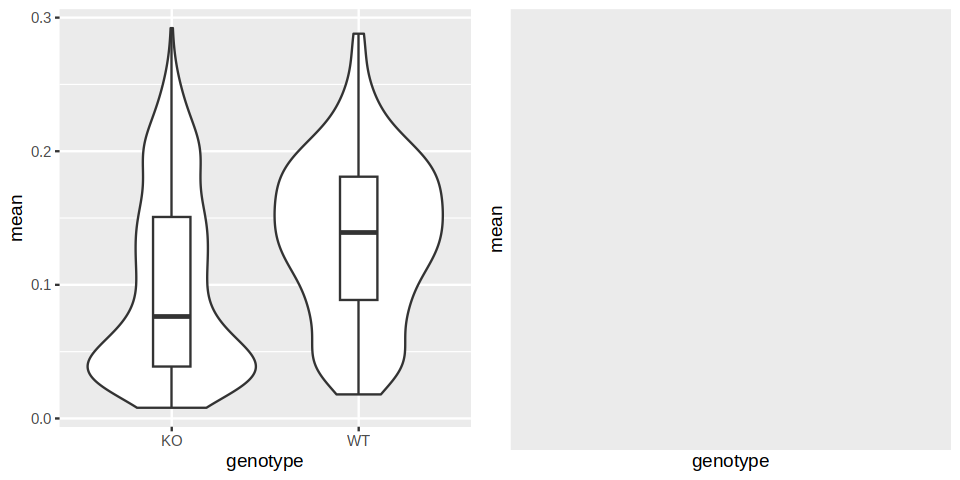

In [496]:
tmp1 = tmp %>% copy %>%
    .[gene %in% markers[sig=='pos', rn]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p1 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

tmp1 = tmp %>% copy %>%
    .[gene %in% markers[sig=='neg', rn]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
p2 = ggplot(tmp1, aes(genotype, mean)) + 
    geom_violin(scale = 'width') + 
    geom_boxplot(width = 0.2)

options(repr.plot.height=4, repr.plot.width = 8)
ggarrange(p1, p2, nrow = 1)

In [503]:
tmp1 = tmp %>% copy %>%
    .[gene %in% markers[sig=='pos', rn]] %>%
    .[, mean := mean(value), by = 'cell'] %>%
    unique(by = 'cell')
head(tmp1)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,celltype_genotype,celltype_extended_genotype,UMAP1,UMAP2,mofa_cluster,celltype_v1,celltype_v2,value,gene,mean
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<dbl>,<fct>,<dbl>
2_Eo_DEG_G9_day4_dTAG#AACAGATAGTTGGATC-1,AACAGATAGTTGGATC-1,2_Eo_DEG_G9_day4_dTAG,3061,8064,9.40,17.88,day4_KO_rep2,D4,KO,⋯,ExE_mesoderm-KO,Lateral_plate_mesoderm-KO,7.482838,1.115844,15,Endothelium,Endothelium,0.0000000,Nrg1,0.01131298
2_Eo_DEG_G9_day4_dTAG#ACGGGAAGTGATGGCT-1,ACGGGAAGTGATGGCT-1,2_Eo_DEG_G9_day4_dTAG,3434,8545,11.83,9.50,day4_KO_rep2,D4,KO,⋯,Endothelium-KO,Venous_endothelium-KO,7.350658,1.376855,15,Endothelium,Endothelium,0.0000000,Nrg1,0.15520370
2_Eo_DEG_G9_day4_dTAG#CACCGGTAGCCTGATG-1,CACCGGTAGCCTGATG-1,2_Eo_DEG_G9_day4_dTAG,4658,14306,3.45,7.99,day4_KO_rep2,D4,KO,⋯,Endothelium-KO,Venous_endothelium-KO,7.353368,1.070421,15,Endothelium,Endothelium,0.0000000,Nrg1,0.09397962
2_Eo_DEG_G9_day4_dTAG#GCATGAAAGCCTGTTC-1,GCATGAAAGCCTGTTC-1,2_Eo_DEG_G9_day4_dTAG,4741,14305,3.38,8.65,day4_KO_rep2,D4,KO,⋯,Endothelium-KO,Venous_endothelium-KO,7.750730,1.967296,15,Endothelium,Endothelium,0.0000000,Nrg1,0.07250890
2_Eo_DEG_G9_day5_dTAG#AAACCGCGTTAATGCG-1,AAACCGCGTTAATGCG-1,2_Eo_DEG_G9_day5_dTAG,4889,15446,5.77,9.59,day5_KO_rep1,D5,KO,⋯,Haematoendothelial_progenitors-KO,Allantois_endothelium-KO,7.507001,3.882644,15,Endothelium,Endothelium,0.0000000,Nrg1,0.04408378
2_Eo_DEG_G9_day5_dTAG#AAAGCAAGTTGCTTCG-1,AAAGCAAGTTGCTTCG-1,2_Eo_DEG_G9_day5_dTAG,4441,13085,4.69,10.37,day5_KO_rep1,D5,KO,⋯,Haematoendothelial_progenitors-KO,Allantois_endothelium-KO,7.474784,3.963420,15,Endothelium,Endothelium,0.2495846,Nrg1,0.02654670


### Integrate data

In [436]:
colnames(colData(rna.sce))
colnames(colData(atlas.sce))

[1] "barcode"                      "sample"                      
 [3] "nFeature_RNA"                 "nCount_RNA"                  
 [5] "mitochondrial_percent_RNA"    "ribosomal_percent_RNA"       
 [7] "alias"                        "day"                         
 [9] "genotype"                     "replicate"                   
[11] "pass_rnaQC"                   "doublet_score"               
[13] "doublet_call"                 "celltype.mapped_mnn"         
[15] "celltype.score_mnn"           "celltype_extended.mapped_mnn"
[17] "celltype_extended.score_mnn"  "stage.mapped_mnn"            
[19] "cellstage.score_mnn"          "closest.cell_mnn"            
[21] "celltype_genotype"            "celltype_extended_genotype"  
[23] "UMAP1"                        "UMAP2"                       
[25] "mofa_cluster"                 "celltype_v1"                 
[27] "celltype_v2"

[1] "barcode"                   "sample"                   
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "stage"                     "genotype"                 
 [9] "pass_rnaQC"                "doublet_score"            
[11] "doublet_call"              "celltype"                 
[13] "celltype.score"            "closest.cell"             
[15] "pass_atacQC"               "seurat_cluster"           
[17] "sizeFactor"

In [437]:
rna.sce2 = rna.sce
colData(rna.sce2) = colData(rna.sce2)[,c('genotype', 'barcode')]

atlas.sce2 = atlas.sce
colData(atlas.sce2) = colData(atlas.sce2)[,c('genotype', 'barcode')]

In [438]:
genes = intersect(rownames(rna.sce2), rownames(atlas.sce2))
sce = cbind(atlas.sce2[genes,], rna.sce2[genes,])

In [439]:
sce$genotype = ifelse(is.na(sce$genotype), 'Atlas', sce$genotype)

In [440]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[gene %in% rownames(rna.sce)]

In [441]:
nrow(top_markers)

[1] 238

In [442]:
library(batchelor)

In [443]:
pca.mtx <- multiBatchPCA(sce[top_markers$gene,], 
                         batch = colData(sce)$genotype, 
                         d = 5,
                         preserve.single=TRUE, 
                         BPPARAM  = BPPARAM)[[1]]
colnames(pca.mtx) <- paste0("PC",1:ncol(pca.mtx))
reducedDim(sce, "PCA") <- pca.mtx[colnames(sce),]

In [444]:
pca.corrected <- reducedMNN(pca.mtx, batch = colData(sce)$genotype, auto.merge = TRUE)$corrected 


In [445]:
reducedDim(sce, "PCA_corrected") <- pca.corrected[colnames(sce),]

In [446]:
to.plot <- as.data.table(pca.corrected, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

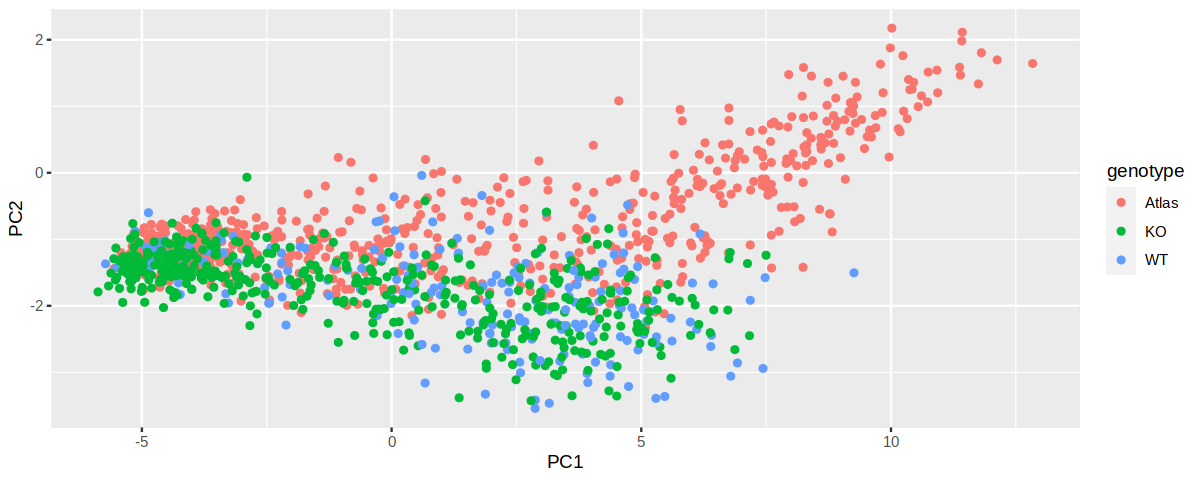

In [447]:
ggplot(to.plot, aes(PC1, PC2, color = genotype)) + 
    geom_point()

In [448]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 15

umap.mtx = uwot::umap(reducedDim(sce, "PCA_corrected")[colnames(sce),], 
                n_neighbors = args$n_neighbors,
                min_dist = args$min_dist)

In [449]:
reducedDim(sce, "UMAP") <- umap.mtx[colnames(sce),]

In [450]:
to.plot <- as.data.table(umap.mtx, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

In [451]:
head(to.plot)

cell,V1,V2,genotype
<chr>,<dbl>,<dbl>,<chr>
E7.5_rep1#ACCTGTTGTCCCGGAA-1,0.9085530,1.4707981,Atlas
E7.5_rep1#CGTGACATCTTTAGGA-1,6.2041031,3.2913874,Atlas
E7.5_rep1#GAGTGATCACCTGCTC-1,5.2352830,-2.5496986,Atlas
E7.5_rep1#TTTGACCGTGATCAGC-1,0.1240324,2.6721669,Atlas
E7.5_rep2#GGAGCGATCATTGACA-1,3.5340458,0.3185250,Atlas
E7.5_rep2#TCTATGTTCCATAAGC-1,3.5933970,0.5007679,Atlas


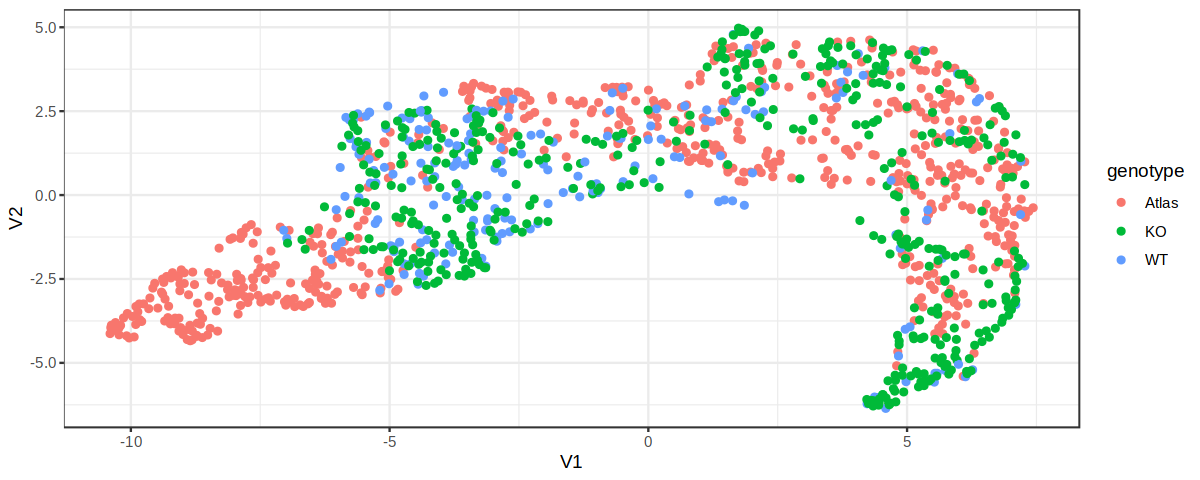

In [452]:
ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point() + 
    theme_bw()

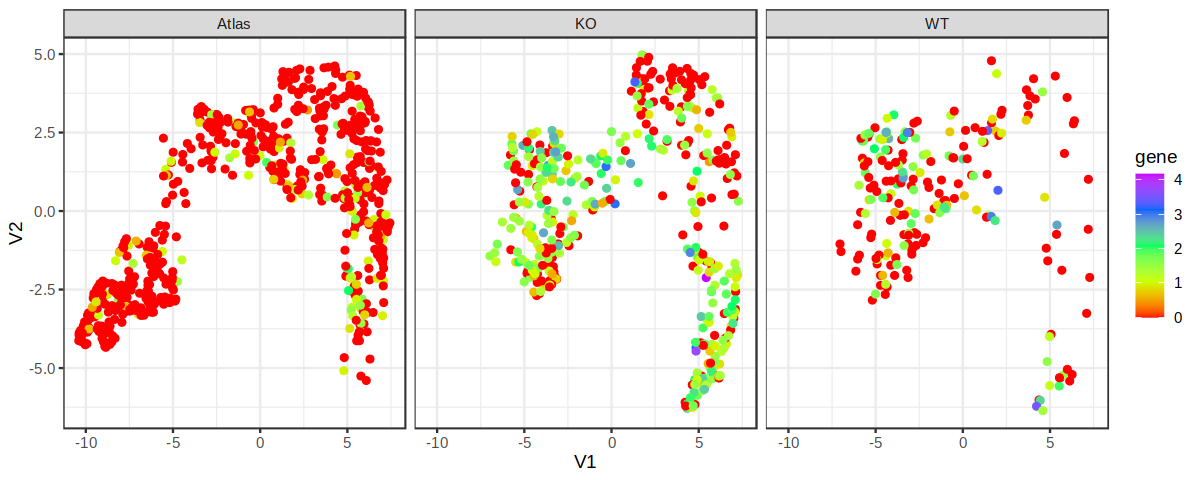

In [453]:
to.plot$gene = as.vector(logcounts(sce['Hand1',]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()

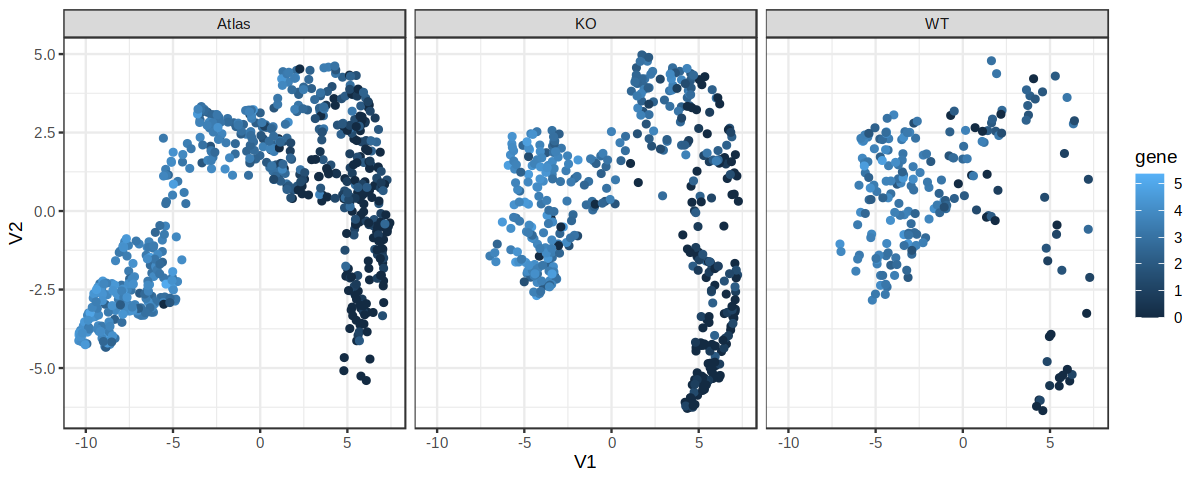

In [519]:
to.plot$gene = as.vector(logcounts(sce['Cdh5',]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    # scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()

In [528]:
seurat_tmp = as.Seurat(rna.sce[,to.plot[V1 < 0 & genotype != 'Atlas', cell]])
Idents(seurat_tmp) = seurat_tmp$genotype
markers = FindMarkers(seurat_tmp, ident.1 = 'WT')

In [525]:
seurat_tmp$genotype

An object of class Seurat 
32285 features across 314 samples within 1 assay 
Active assay: RNA (32285 features, 0 variable features)

### Integrate data

In [10]:
# Load Atlas
args$atlas.sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/endothelium/endothelium_sce.rds'
atlas.sce = load_SingleCellExperiment(args$atlas.sce, normalise = TRUE) 
atlas.sce = atlas.sce[,atlas.sce$seurat_cluster %in% c('EryP_progenitor')]

In [11]:
atlas_meta = colData(atlas.sce) %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [12]:
colnames(colData(rna.sce))
colnames(colData(atlas.sce))

[1] "barcode"                      "sample"                      
 [3] "nFeature_RNA"                 "nCount_RNA"                  
 [5] "mitochondrial_percent_RNA"    "ribosomal_percent_RNA"       
 [7] "alias"                        "day"                         
 [9] "genotype"                     "replicate"                   
[11] "pass_rnaQC"                   "doublet_score"               
[13] "doublet_call"                 "celltype.mapped_mnn"         
[15] "celltype.score_mnn"           "celltype_extended.mapped_mnn"
[17] "celltype_extended.score_mnn"  "stage.mapped_mnn"            
[19] "cellstage.score_mnn"          "closest.cell_mnn"            
[21] "celltype_genotype"            "celltype_extended_genotype"  
[23] "UMAP1"                        "UMAP2"                       
[25] "mofa_cluster"                 "celltype_v1"                 
[27] "celltype_v2"

[1] "barcode"                   "sample"                   
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "stage"                     "genotype"                 
 [9] "pass_rnaQC"                "doublet_score"            
[11] "doublet_call"              "celltype"                 
[13] "celltype.score"            "closest.cell"             
[15] "pass_atacQC"               "seurat_cluster"           
[17] "sizeFactor"

In [13]:
rna.sce2 = rna.sce
colData(rna.sce2) = colData(rna.sce2)[,c('genotype', 'barcode')]

atlas.sce2 = atlas.sce
colData(atlas.sce2) = colData(atlas.sce2)[,c('genotype', 'barcode')]

In [14]:
genes = intersect(rownames(rna.sce2), rownames(atlas.sce2))
sce = cbind(atlas.sce2[genes,], rna.sce2[genes,])

In [15]:
sce$genotype = ifelse(is.na(sce$genotype), 'Atlas', sce$genotype)

In [16]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[gene %in% rownames(rna.sce)]

In [17]:
nrow(top_markers)

[1] 238

In [18]:
library(batchelor)

In [31]:
decomp <- modelGeneVar(rna.sce2[genes,])
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=500) %>% rownames

In [32]:
head(hvgs, 20)

[1] "Ptprm"      "Meg3"       "Rian"       "Mast4"      "Airn"      
 [6] "Flt1"       "Col18a1"    "Ctla2a"     "Mecom"      "Hist1h2ap" 
[11] "Vcan"       "Rapgef5"    "Limch1"     "Hmga2"      "Dlk1"      
[16] "Unc5c"      "St6galnac3" "Edil3"      "Camk1d"     "Igf2"

In [33]:
pca.mtx <- multiBatchPCA(sce[hvgs,], 
                         batch = colData(sce)$genotype, 
                         d = 5,
                         preserve.single=TRUE, 
                         BPPARAM  = BPPARAM)[[1]]
colnames(pca.mtx) <- paste0("PC",1:ncol(pca.mtx))
reducedDim(sce, "PCA") <- pca.mtx[colnames(sce),]

In [34]:
pca.corrected <- reducedMNN(pca.mtx, batch = colData(sce)$genotype, auto.merge = TRUE)$corrected 


In [35]:
reducedDim(sce, "PCA_corrected") <- pca.corrected[colnames(sce),]

In [36]:
to.plot <- as.data.table(pca.corrected, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

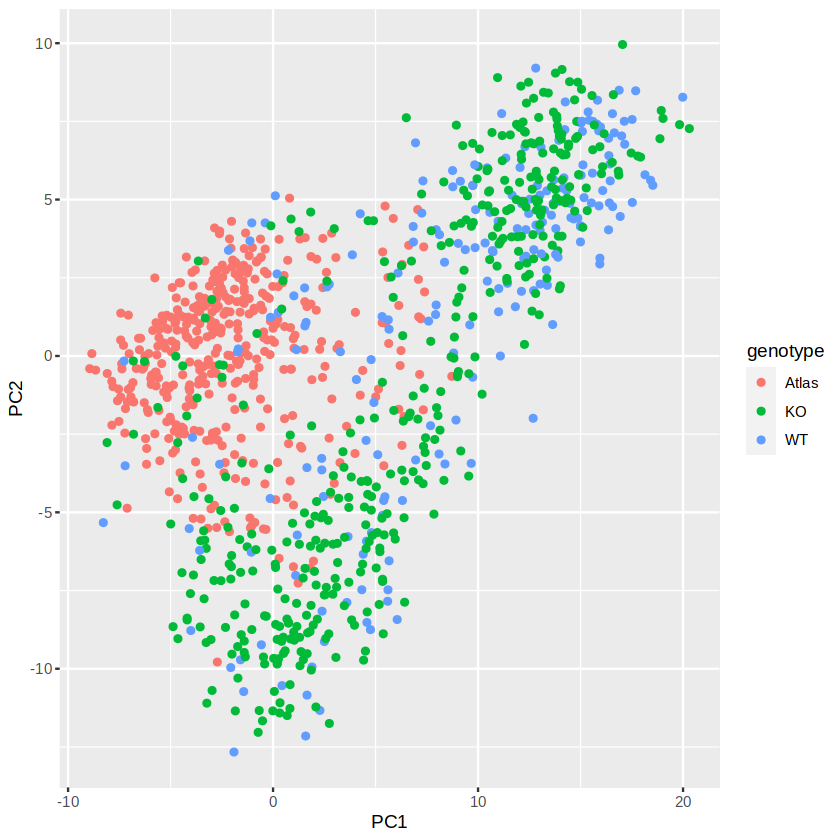

In [37]:
ggplot(to.plot, aes(PC1, PC2, color = genotype)) + 
    geom_point()

In [38]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 15

umap.mtx = uwot::umap(reducedDim(sce, "PCA_corrected")[colnames(sce),], 
                n_neighbors = args$n_neighbors,
                min_dist = args$min_dist)

In [39]:
reducedDim(sce, "UMAP") <- umap.mtx[colnames(sce),]

In [40]:
to.plot <- as.data.table(umap.mtx, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

In [41]:
head(to.plot)

cell,V1,V2,genotype
<chr>,<dbl>,<dbl>,<chr>
E7.5_rep1#AAACCGGCAACCTAAT-1,-0.3331607,0.780041,Atlas
E7.5_rep1#AACCTTAAGTCCTTTG-1,-0.5642348,1.062203,Atlas
E7.5_rep1#AACGCCCAGGTCCAAT-1,0.0725172,1.241873,Atlas
E7.5_rep1#AAGCCACGTCCGCTGT-1,3.2244231,-2.819947,Atlas
E7.5_rep1#AAGCGCTGTTAAGCTG-1,0.2609158,0.503876,Atlas
E7.5_rep1#AAGGCCCTCACGAATC-1,2.4889537,3.165922,Atlas


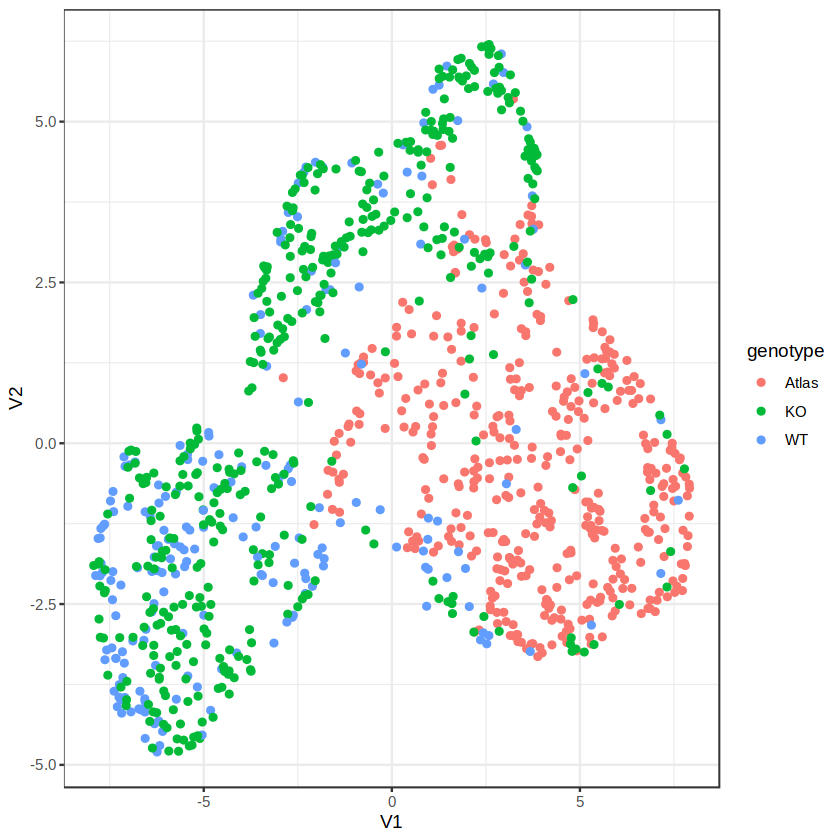

In [42]:
ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point() + 
    theme_bw()

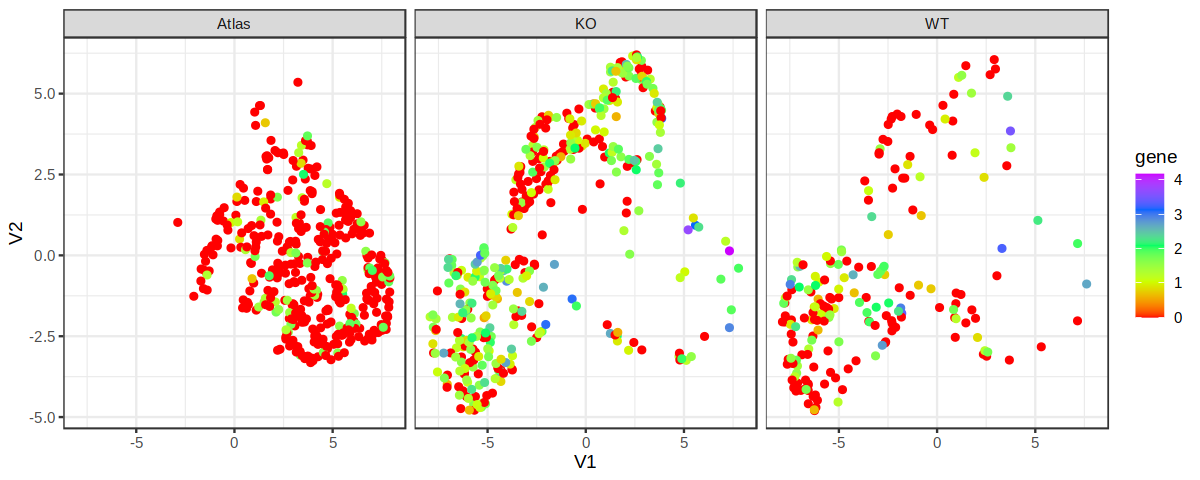

In [43]:
to.plot$gene = as.vector(logcounts(sce['Hand1',]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()

In [44]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[gene %in% rownames(rna.sce)]

In [46]:
nrow(top_markers)

[1] 238

In [59]:
sce$origin = ifelse(sce$genotype == 'Atlas', 'Atlas', 'Vitro')

In [60]:
pca.mtx <- multiBatchPCA(sce[top_markers$gene,], 
                         batch = colData(sce)$origin, 
                         d = 5,
                         preserve.single=TRUE, 
                         BPPARAM  = BPPARAM)[[1]]
colnames(pca.mtx) <- paste0("PC",1:ncol(pca.mtx))
reducedDim(sce, "PCA") <- pca.mtx[colnames(sce),]

In [61]:
pca.corrected <- reducedMNN(pca.mtx, batch = colData(sce)$origin, auto.merge = TRUE)$corrected 


In [62]:
reducedDim(sce, "PCA_corrected") <- pca.corrected[colnames(sce),]

In [63]:
to.plot <- as.data.table(pca.corrected, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

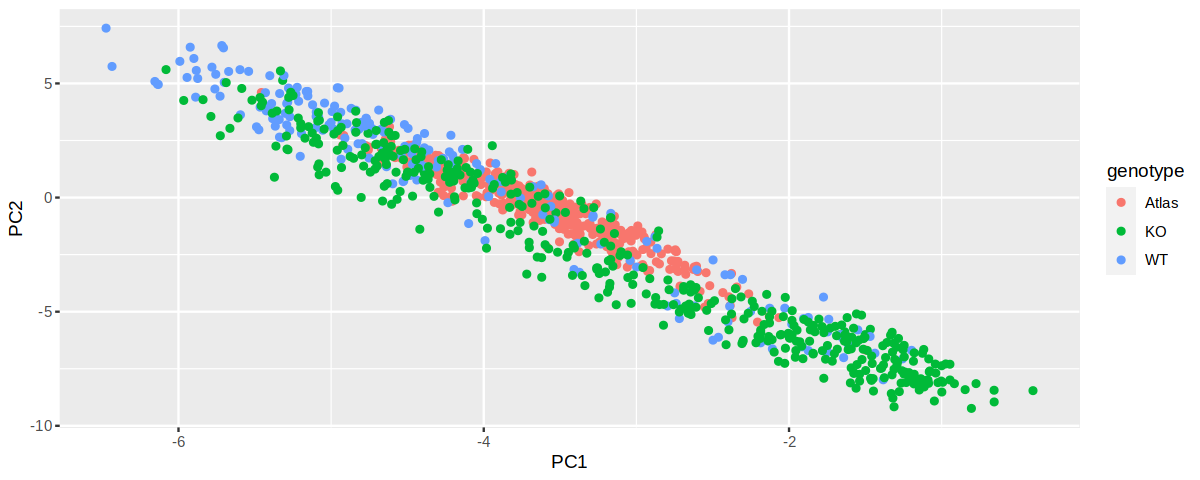

In [64]:
ggplot(to.plot, aes(PC1, PC2, color = genotype)) + 
    geom_point()

In [65]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 15

umap.mtx = uwot::umap(reducedDim(sce, "PCA_corrected")[colnames(sce),], 
                n_neighbors = args$n_neighbors,
                min_dist = args$min_dist)

In [66]:
reducedDim(sce, "UMAP") <- umap.mtx[colnames(sce),]

In [67]:
to.plot <- as.data.table(umap.mtx, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

In [68]:
head(to.plot)

cell,V1,V2,genotype
<chr>,<dbl>,<dbl>,<chr>
E7.5_rep1#AAACCGGCAACCTAAT-1,6.3648713,-1.9797567,Atlas
E7.5_rep1#AACCTTAAGTCCTTTG-1,3.9696775,-1.3479355,Atlas
E7.5_rep1#AACGCCCAGGTCCAAT-1,-0.5122149,1.4166883,Atlas
E7.5_rep1#AAGCCACGTCCGCTGT-1,2.9172762,-1.1979200,Atlas
E7.5_rep1#AAGCGCTGTTAAGCTG-1,-0.1206596,0.2390002,Atlas
E7.5_rep1#AAGGCCCTCACGAATC-1,-1.6054210,0.7635810,Atlas


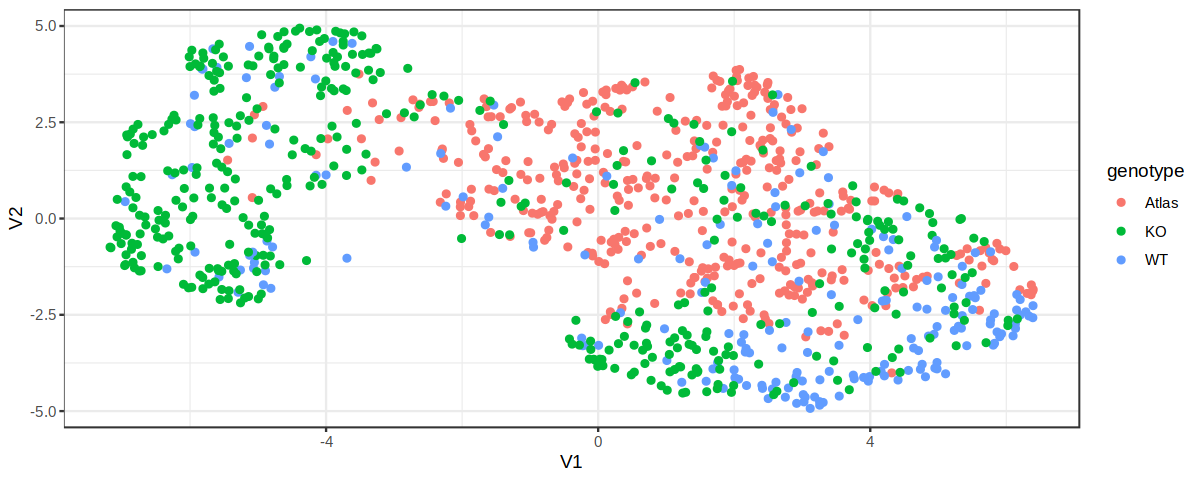

In [69]:
ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point() + 
    theme_bw()

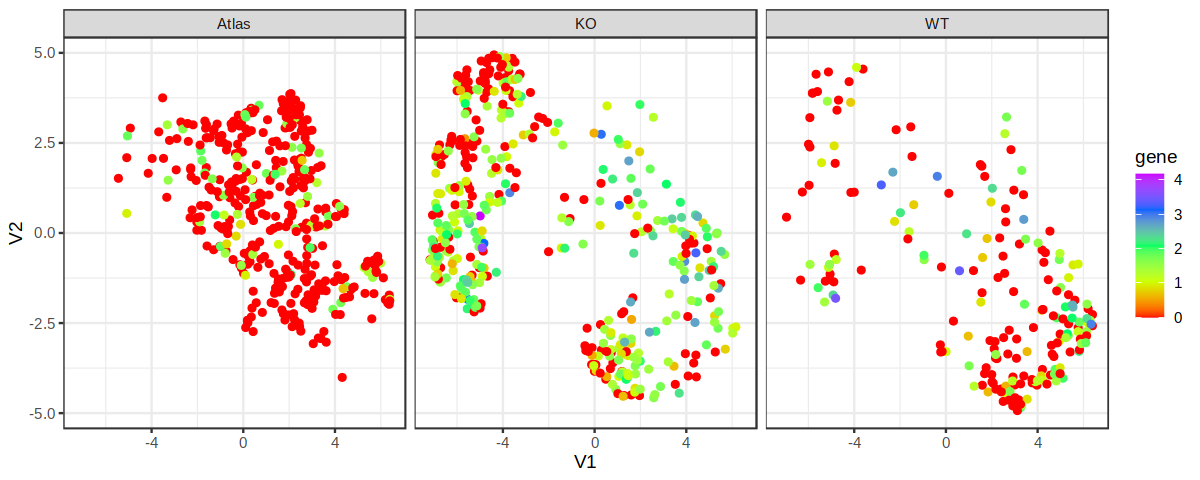

In [70]:
to.plot$gene = as.vector(logcounts(sce['Hand1',]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot, aes(V1, V2, color = gene)) + 
    geom_point() + 
    scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()

# scRNA-seq atlas

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/SingleCellExperiment.rds"

In [182]:
# Load Atlas
args$atlas.sce = io$rna.atlas.sce
atlas.sce = load_SingleCellExperiment(args$atlas.sce, normalise = TRUE) 

In [183]:
atlas_meta = fread(file.path(io$atlas.basedir, 'sample_metadata_extended.txt.gz'))

In [184]:
unique(atlas_meta$celltype)

[1] "Epiblast"                       "Primitive_Streak"              
 [3] "ExE_ectoderm"                   "Visceral_endoderm"             
 [5] "ExE_endoderm"                   "Nascent_mesoderm"              
 [7] "Rostral_neurectoderm"           "Blood_progenitors_2"           
 [9] "Mixed_mesoderm"                 "ExE_mesoderm"                  
[11] "Intermediate_mesoderm"          "Pharyngeal_mesoderm"           
[13] "Caudal_epiblast"                "PGC"                           
[15] "Mesenchyme"                     "Haematoendothelial_progenitors"
[17] "Blood_progenitors_1"            "Surface_ectoderm"              
[19] "Gut"                            "Paraxial_mesoderm"             
[21] "Caudal_neurectoderm"            "Notochord"                     
[23] "Somitic_mesoderm"               "Caudal_Mesoderm"               
[25] "Erythroid1"                     "Def._endoderm"                 
[27] "Parietal_endoderm"              "Allantois"                     
[29] "Anterior_Primitive_Streak"      "Endothelium"                   
[31] "Forebrain_Midbrain_Hindbrain"   "Spinal_cord"                   
[33] "Cardiomyocytes"                 "Erythroid2"                    
[35] "NMP"                            "Erythroid3"                    
[37] "Neural_crest"

In [185]:
colData(atlas.sce) = atlas_meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [186]:
atlas.sce = atlas.sce[, atlas_meta$cell]

In [187]:
genes = fread(io$gene_metadata)

In [188]:
atlas.sce = atlas.sce[rownames(atlas.sce) %in% genes$ens_id,]
rownames(atlas.sce) = genes[match(rownames(atlas.sce), ens_id),]$symbol

In [189]:
atlas.sce

class: SingleCellExperiment 
dim: 28517 116312 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(28517): Xkr4 Gm1992 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(116312): cell_1 cell_2 ... cell_139330 cell_139331
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [190]:
atlas.sce = atlas.sce[,atlas.sce$celltype %in% c('Endothelium', 'Haematoendothelial_progenitors')]

In [191]:
colnames(colData(rna.sce))
colnames(colData(atlas.sce))

[1] "barcode"                      "sample"                      
 [3] "nFeature_RNA"                 "nCount_RNA"                  
 [5] "mitochondrial_percent_RNA"    "ribosomal_percent_RNA"       
 [7] "alias"                        "day"                         
 [9] "genotype"                     "replicate"                   
[11] "pass_rnaQC"                   "doublet_score"               
[13] "doublet_call"                 "celltype.mapped_mnn"         
[15] "celltype.score_mnn"           "celltype_extended.mapped_mnn"
[17] "celltype_extended.score_mnn"  "stage.mapped_mnn"            
[19] "cellstage.score_mnn"          "closest.cell_mnn"            
[21] "celltype_genotype"            "celltype_extended_genotype"  
[23] "UMAP1"                        "UMAP2"                       
[25] "mofa_cluster"                 "celltype_v1"                 
[27] "celltype_v2"

[1] "barcode"           "sample"            "stage"            
 [4] "sequencing.batch"  "doublet"           "stripped"         
 [7] "celltype"          "umapX"             "umapY"            
[10] "nFeature_RNA"      "nCount_RNA"        "index"            
[13] "celltype_extended"

In [192]:
atlas.sce

class: SingleCellExperiment 
dim: 28517 3817 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(28517): Xkr4 Gm1992 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(3817): cell_407 cell_419 ... cell_139265 cell_139266
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [193]:
rna.sce2 = rna.sce
colData(rna.sce2) = colData(rna.sce2)[,c('genotype', 'barcode')]

atlas.sce2 = atlas.sce
atlas.sce2$genotype = 'Atlas'
colData(atlas.sce2) = colData(atlas.sce2)[,c('genotype', 'barcode')]

In [194]:
colData(atlas.sce2)

DataFrame with 3817 rows and 2 columns
               genotype        barcode
            <character>    <character>
cell_407          Atlas ACTATCACATTCCT
cell_419          Atlas AGACTCGATTGCAG
cell_427          Atlas AGCTCGCTAGTCAC
cell_469          Atlas CACGAAACTGCATG
cell_515          Atlas CCTGGACTCCATGA
...                 ...            ...
cell_139116       Atlas TGTACTTGCAGTTG
cell_139240       Atlas TTCGATTGTTGACG
cell_139261       Atlas TTGAATGATATCTC
cell_139265       Atlas TTGACACTAGGGTG
cell_139266       Atlas TTGACACTCGAGTT

In [195]:
colData(rna.sce2)

DataFrame with 637 rows and 2 columns
                                            genotype            barcode
                                         <character>        <character>
2_Eo_DEG_G9_day4_VC#GTACTGGTCTTAAGTG-1            WT GTACTGGTCTTAAGTG-1
2_Eo_DEG_G9_day4_VC#TGGACCGGTTGGGTTA-1            WT TGGACCGGTTGGGTTA-1
2_Eo_DEG_G9_day4_VC#TGTGCACCAGCAAGGC-1            WT TGTGCACCAGCAAGGC-1
2_Eo_DEG_G9_day4_dTAG#AACAGATAGTTGGATC-1          KO AACAGATAGTTGGATC-1
2_Eo_DEG_G9_day4_dTAG#ACGGGAAGTGATGGCT-1          KO ACGGGAAGTGATGGCT-1
...                                              ...                ...
rv_eo_deg_day4_dtag#GGTTAATGTCACTCGC-1            KO GGTTAATGTCACTCGC-1
rv_eo_deg_day4_dtag#GTTCACCTCACAGCGC-1            KO GTTCACCTCACAGCGC-1
rv_eo_deg_day4_dtag#TATCACGCATTGCAGC-1            KO TATCACGCATTGCAGC-1
rv_eo_deg_day4_dtag#TCGTTTCCAATAATGG-1            KO TCGTTTCCAATAATGG-1
rv_eo_deg_day4_dtag#TGAGTGAAGCTGTACG-1            KO TGAGTGAAGCTGTACG-1

In [196]:
rna.sce2
atlas.sce2

class: SingleCellExperiment 
dim: 32285 637 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(637): 2_Eo_DEG_G9_day4_VC#GTACTGGTCTTAAGTG-1
  2_Eo_DEG_G9_day4_VC#TGGACCGGTTGGGTTA-1 ...
  rv_eo_deg_day4_dtag#TCGTTTCCAATAATGG-1
  rv_eo_deg_day4_dtag#TGAGTGAAGCTGTACG-1
colData names(2): genotype barcode
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

class: SingleCellExperiment 
dim: 28517 3817 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(28517): Xkr4 Gm1992 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(3817): cell_407 cell_419 ... cell_139265 cell_139266
colData names(2): genotype barcode
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [197]:
atlas.sce2@int_colData$size_factor = NULL

In [198]:
rna.sce2@metadata
atlas.sce2@metadata

list()

$log.exprs.offset
[1] 1

In [200]:
genes = intersect(rownames(atlas.sce2), rownames(rna.sce2))

In [201]:
  sce <- SingleCellExperiment::SingleCellExperiment(
    list(counts=Matrix::Matrix(cbind(counts(atlas.sce2[genes,]),counts(rna.sce2[genes,])),sparse=TRUE)))

In [202]:
sce

class: SingleCellExperiment 
dim: 26550 4454 
metadata(0):
assays(1): counts
rownames(26550): Xkr4 Gm1992 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(4454): cell_407 cell_419 ...
  rv_eo_deg_day4_dtag#TCGTTTCCAATAATGG-1
  rv_eo_deg_day4_dtag#TGAGTGAAGCTGTACG-1
colData names(0):
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [203]:
sce$genotype = c(rep('Atlas', ncol(atlas.sce2)), rna.sce2$genotype)

In [204]:
sce$origin = ifelse(sce$genotype == 'Atlas', 'Atlas', 'Vitro')

In [205]:
top_markers = subset_markers %>% 
    .[cluster != 'embryo'] %>%
    .[gene %in% rownames(rna.sce)]

In [206]:
nrow(top_markers)

[1] 238

In [207]:
library(batchelor)

In [208]:
decomp <- modelGeneVar(rna.sce2[genes,])
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=500) %>% rownames

In [209]:
head(hvgs, 20)

[1] "Ptprm"      "Meg3"       "Mast4"      "Airn"       "Flt1"      
 [6] "Col18a1"    "Ctla2a"     "Mecom"      "Hist1h2ap"  "Vcan"      
[11] "Rapgef5"    "Limch1"     "Hmga2"      "Dlk1"       "St6galnac3"
[16] "Unc5c"      "Edil3"      "Igf2"       "Camk1d"     "Grip1"

In [210]:
sce <- multiBatchNorm(sce, batch=sce$origin)

In [211]:
pca.mtx <- multiBatchPCA(sce[top_markers[gene %in% rownames(sce)]$gene,],
                         batch = colData(sce)$origin, 
                         d = 5,
                         preserve.single=TRUE, 
                         BPPARAM  = BPPARAM)[[1]]
colnames(pca.mtx) <- paste0("PC",1:ncol(pca.mtx))
reducedDim(sce, "PCA") <- pca.mtx[colnames(sce),]

In [212]:
head(colData(sce)$origin)

[1] "Atlas" "Atlas" "Atlas" "Atlas" "Atlas" "Atlas"

In [213]:
pca.corrected <- reducedMNN(pca.mtx, batch = colData(sce)$origin, auto.merge = TRUE)$corrected 


In [214]:
reducedDim(sce, "PCA_corrected") <- pca.corrected[colnames(sce),]

In [215]:
to.plot <- as.data.table(pca.corrected, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

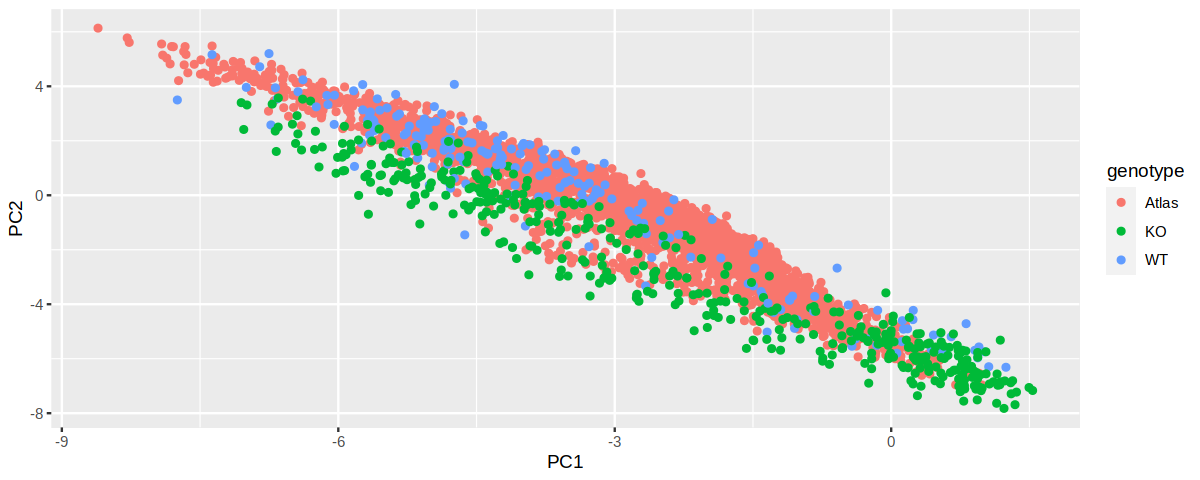

In [216]:
ggplot(to.plot, aes(PC1, PC2, color = genotype)) + 
    geom_point()

In [217]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 15

umap.mtx = uwot::umap(reducedDim(sce, "PCA_corrected")[colnames(sce),], 
                n_neighbors = args$n_neighbors,
                min_dist = args$min_dist)

In [218]:
reducedDim(sce, "UMAP") <- umap.mtx[colnames(sce),]

In [219]:
to.plot <- as.data.table(umap.mtx, keep.rownames=T) %>% setnames('rn', 'cell') %>% as.data.table %>% 
    .[,cell:=colnames(sce)] %>% 
    .[,genotype := colData(sce)$genotype]

In [220]:
head(to.plot)

cell,V1,V2,genotype
<chr>,<dbl>,<dbl>,<chr>
cell_407,7.915417,2.3218739,Atlas
cell_419,5.772999,1.5871459,Atlas
cell_427,6.096707,-0.8521180,Atlas
cell_469,1.679251,3.0780360,Atlas
cell_515,7.846014,-0.1641739,Atlas
cell_549,2.563043,3.5421795,Atlas


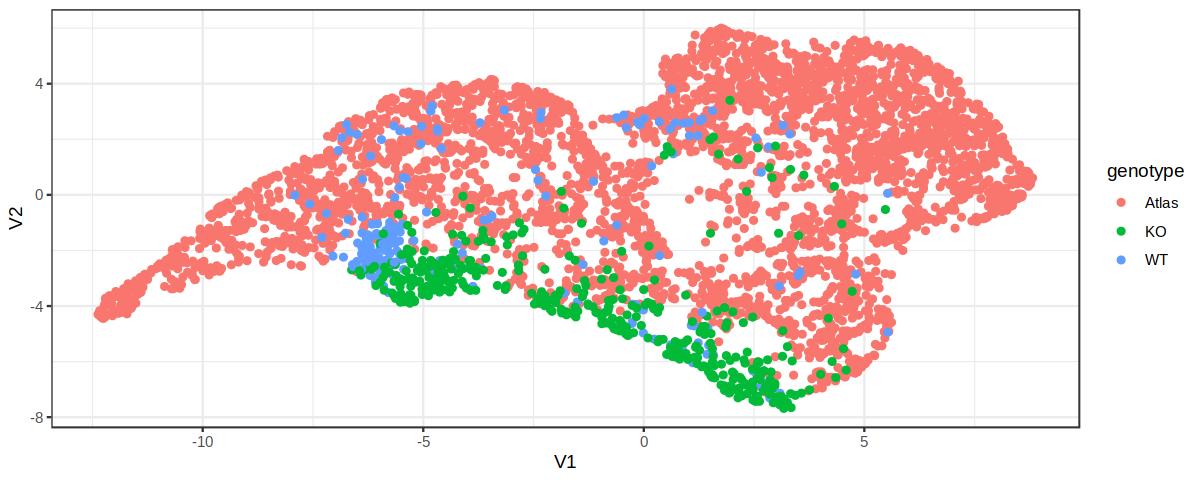

In [221]:
ggplot(to.plot, aes(V1, V2, color = genotype)) + 
    geom_point() + 
    theme_bw()

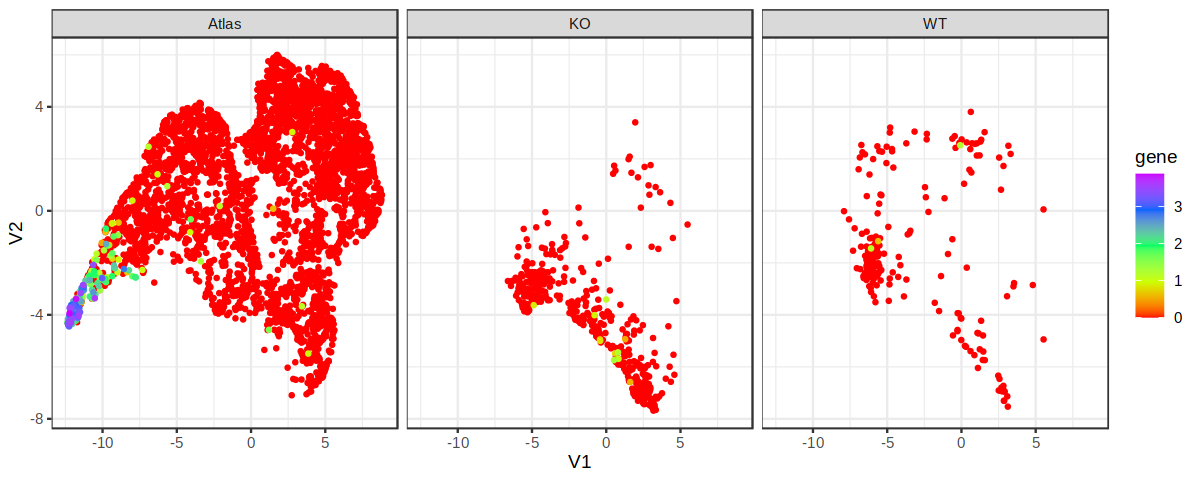

In [230]:
to.plot$gene = as.vector(logcounts(sce['Stab2',to.plot$cell]))
options(repr.plot.height=4, repr.plot.width = 10)
ggplot(to.plot[order(gene)], aes(V1, V2, color = gene)) + 
    geom_point(size = 0.8) + 
    scale_color_gradientn(colours = rainbow(5)) + 
    facet_wrap(~genotype) + 
    theme_bw()